# Modelo IAN-R1 MTR
This notebook can be used as a template for modeling TRIGA reactors.

In [1]:
%matplotlib inline
import numpy as np
import openmc

In [2]:
#Materiales

import openmc

#Moderador (agua)
water = openmc.Material(name='Light Water')
water.set_density('g/cm3', 0.997)
water.add_element('H', 2.0, 'ao')
water.add_element('O', 1.0, 'ao')
water.add_s_alpha_beta('c_H_in_H2O')

#Revestimiento
al1100 = openmc.Material(name='Aluminum 1100')
al1100.set_density('g/cm3', 2.71)
al1100.add_element('Al', 1.0, 'wo')

#Combustible
u_al_meat = openmc.Material(name='U-Al Fuel Meat')
u_al_meat.set_density('g/cm3', 3.32667)
u_al_meat.add_nuclide('U235', 0.2411, 'wo')
u_al_meat.add_nuclide('U238', 0.0268, 'wo')
u_al_meat.add_element('Al', 0.7321, 'wo')

#Reflector
graphite = openmc.Material(name='Graphite')
graphite.set_density('g/cm3', 1.70)
graphite.add_element('C', 1.0)
graphite.add_s_alpha_beta('c_Graphite')

#Control
borated_ss = openmc.Material(name='Borated SS304')
borated_ss.set_density('g/cm3', 7.9)
borated_ss.add_nuclide('B10', 0.0135, 'wo')
borated_ss.add_element('C',  0.002 * 0.9865, 'wo')
borated_ss.add_element('Si', 0.004 * 0.9865, 'wo')
borated_ss.add_element('Cr', 0.115 * 0.9865, 'wo')
borated_ss.add_element('Fe', 0.8495 * 0.9865, 'wo')
borated_ss.add_element('Ni', 0.005 * 0.9865, 'wo')

#Aire-irradiacion
air = openmc.Material(name='Air')
air.set_density('g/cm3', 0.001205)
air.add_element('N', 0.755268, 'wo')
air.add_element('O', 0.231781, 'wo')
air.add_element('Ar', 0.012827, 'wo')

#Exportar a XML
materials_file = openmc.Materials([water, al1100, u_al_meat, graphite, borated_ss, air])
materials_file.export_to_xml()

In [3]:
#Definciones del reactor

#Ancho (cm)
meat_thickness = 0.0508  
clad_thickness = 0.0508  
plate_thickness = meat_thickness + (2 * clad_thickness)
water_gap = 0.55          

meat_width = 6.23        
plate_width = meat_width + (2 * clad_thickness) 
active_height = 59.37    

box_outer_pitch = 7.62   
box_wall_thick = 0.3     
box_inner_pitch = box_outer_pitch - (2 * box_wall_thick) # 7.02 cm

# Planos (cm)
z_center = -36.03
z_bot = openmc.ZPlane(z0=z_center - active_height/2)
z_top = openmc.ZPlane(z0=z_center + active_height/2)
x_meat_min = openmc.XPlane(x0=-meat_width/2)
x_meat_max = openmc.XPlane(x0=meat_width/2)
x_plate_min = openmc.XPlane(x0=-plate_width/2)
x_plate_max = openmc.XPlane(x0=plate_width/2)


x_box_out_min = openmc.XPlane(x0=-box_outer_pitch/2)
x_box_out_max = openmc.XPlane(x0=box_outer_pitch/2)
y_box_out_min = openmc.YPlane(y0=-box_outer_pitch/2)
y_box_out_max = openmc.YPlane(y0=box_outer_pitch/2)

x_box_in_min = openmc.XPlane(x0=-box_inner_pitch/2)
x_box_in_max = openmc.XPlane(x0=box_inner_pitch/2)
y_box_in_min = openmc.YPlane(y0=-box_inner_pitch/2)
y_box_in_max = openmc.YPlane(y0=box_inner_pitch/2)

#Cavidad
inner_cavity_region = +x_box_in_min & -x_box_in_max & +y_box_in_min & -y_box_in_max & +z_bot & -z_top

water_flow_region = +x_plate_min & -x_plate_max & +y_box_in_min & -y_box_in_max & +z_bot & -z_top

side_plates_region = inner_cavity_region & ~water_flow_region

#Combustible

fuel_universe = openmc.Universe(name='Standard 10-Plate Element')

total_stack_thick = 10 * plate_thickness + 9 * water_gap # 4.224 cm
y_curr = -total_stack_thick / 2

standard_cells = []

for i in range(10):
    p_y_min = openmc.YPlane(y0=y_curr)
    p_y_max = openmc.YPlane(y0=y_curr + plate_thickness)
    m_y_min = openmc.YPlane(y0=y_curr + clad_thickness)
    m_y_max = openmc.YPlane(y0=y_curr + clad_thickness + meat_thickness)
    
    meat_reg = +x_meat_min & -x_meat_max & +m_y_min & -m_y_max & +z_bot & -z_top
    standard_cells.append(openmc.Cell(fill=u_al_meat, region=meat_reg))
    
    clad_reg = (+x_plate_min & -x_plate_max & +p_y_min & -p_y_max & +z_bot & -z_top) & ~meat_reg
    standard_cells.append(openmc.Cell(fill=al1100, region=clad_reg))
    
    y_curr += plate_thickness + water_gap

plates_region = openmc.Union([c.region for c in standard_cells])

#Celdas
water_inside = openmc.Cell(name='Coolant', fill=water, region=water_flow_region & ~plates_region)
side_plates = openmc.Cell(name='Side Plates', fill=al1100, region=side_plates_region)
box_region = (+x_box_out_min & -x_box_out_max & +y_box_out_min & -y_box_out_max & +z_bot & -z_top) & ~inner_cavity_region
outer_box = openmc.Cell(name='Outer Box', fill=al1100, region=box_region)

water_out_top = openmc.Cell(name='Water Above', fill=water, region=+x_box_out_min & -x_box_out_max & +y_box_out_min & -y_box_out_max & +z_top)
water_out_bot = openmc.Cell(name='Water Below', fill=water, region=+x_box_out_min & -x_box_out_max & +y_box_out_min & -y_box_out_max & -z_bot)

standard_cells.extend([water_inside, side_plates, outer_box, water_out_top, water_out_bot])
fuel_universe.add_cells(standard_cells)


#Control

control_universe = openmc.Universe(name='Control 6-Plate Element')

z_ext = 0  #Altura de Extracción
z_cr_bot = openmc.ZPlane(z0=(z_center - active_height/2) + z_ext)
z_cr_top = openmc.ZPlane(z0=(z_center + active_height/2) + z_ext)

control_cells = []
static_control_cells = []
y_curr = -total_stack_thick / 2

cr_y_min = None
cr_y_max = None

#Celdas

for i in range(10):
    p_y_min = openmc.YPlane(y0=y_curr)
    p_y_max = openmc.YPlane(y0=y_curr + plate_thickness)
    
    if i in [0, 1, 2, 7, 8, 9]: 
        m_y_min = openmc.YPlane(y0=y_curr + clad_thickness)
        m_y_max = openmc.YPlane(y0=y_curr + clad_thickness + meat_thickness)
        
        meat_reg = +x_meat_min & -x_meat_max & +m_y_min & -m_y_max & +z_bot & -z_top
        static_control_cells.append(openmc.Cell(fill=u_al_meat, region=meat_reg))
        
        clad_reg = (+x_plate_min & -x_plate_max & +p_y_min & -p_y_max & +z_bot & -z_top) & ~meat_reg
        static_control_cells.append(openmc.Cell(fill=al1100, region=clad_reg))
    else:
        if i == 3: cr_y_min = p_y_min
        if i == 6: cr_y_max = p_y_max
            
    y_curr += plate_thickness + water_gap

control_cells.extend(static_control_cells)
cr_slot_region = +x_plate_min & -x_plate_max & +cr_y_min & -cr_y_max
control_rod_region = cr_slot_region & +z_cr_bot & -z_cr_top
control_cells.append(openmc.Cell(name='Control Rod', fill=borated_ss, region=control_rod_region))
follower_region = cr_slot_region & +z_bot & -z_cr_bot
control_cells.append(openmc.Cell(name='CR Follower', fill=water, region=follower_region))
c_plates_region = openmc.Union([c.region for c in static_control_cells])
c_water_inside = openmc.Cell(name='Coolant', fill=water, 
                             region=water_flow_region & ~c_plates_region & ~cr_slot_region & +z_bot & -z_top)
c_side_plates = openmc.Cell(name='Side Plates', fill=al1100, region=side_plates_region)
c_outer_box = openmc.Cell(name='Outer Box', fill=al1100, region=box_region)
c_water_out_top = openmc.Cell(name='Water Above', fill=water, 
                              region=(+x_box_out_min & -x_box_out_max & +y_box_out_min & -y_box_out_max & +z_top) & ~control_rod_region)
c_water_out_bot = openmc.Cell(name='Water Below', fill=water, 
                              region=(+x_box_out_min & -x_box_out_max & +y_box_out_min & -y_box_out_max & -z_bot) & ~control_rod_region)

control_cells.extend([c_water_inside, c_side_plates, c_outer_box, c_water_out_top, c_water_out_bot])
control_universe.add_cells(control_cells)

In [4]:
#Agua alrededor del arreglo

all_water_cell = openmc.Cell(fill=water)
outer_universe = openmc.Universe(cells=(all_water_cell,))

In [5]:
#Grilla

#Posición libre (Agua)
water_cell = openmc.Cell(name='Water Pool', fill=water)
water_univ = openmc.Universe(name='Water Universe', cells=[water_cell])

#Reflector
graphite_cell = openmc.Cell(name='Solid Graphite', fill=graphite)
graphite_univ = openmc.Universe(name='Graphite Universe', cells=[graphite_cell])

#Irradiación 
irrad_cyl = openmc.ZCylinder(r=1.9)
irrad_air_cell = openmc.Cell(name='Irradiation Channel', fill=air, region=-irrad_cyl)
irrad_graphite_cell = openmc.Cell(name='Graphite Matrix', fill=graphite, region=+irrad_cyl)
irrad_graphite_univ = openmc.Universe(name='Irrad Graphite Universe', cells=[irrad_air_cell, irrad_graphite_cell])

#Creacion de consjuntos 2x2

bundle_pitch = 7.62 

core_lattice = openmc.RectLattice(name='IAN-R1 MTR Core Lattice')
core_lattice.lower_left = (-3 * bundle_pitch, -3 * bundle_pitch)
core_lattice.pitch = (bundle_pitch, bundle_pitch)

W  = water_univ           #Agua
G  = graphite_univ        #Grafito
GI = irrad_graphite_univ  #Grafito Irradiación
F  = fuel_universe        #Combustible 10 placas
C  = control_universe     #Elemento de control 6 placas + barra

core_lattice.universes = [
    # Fila 1
    [W, G, G, G, G, W],
    # Fila 2
    [G, F, F, C, F, G],
    # Fila 3
    [G, F, F, F, F, G],
    # Fila 4
    [G, C, F, C, F, G], 
    # Fila 5
    [G, F, F, F, F, G], 
    # Fila 6: Todos reflectores de grafito para irradiación (A6 a F6)
    [GI, GI, GI, GI, GI, GI]
]

# Encapsular la grilla terminada en el universo contenedor del nucleo
core_cell = openmc.Cell(name='Main Core Cell', fill=core_lattice)
bundle_universe = openmc.Universe(name='Core Universe Container', cells=[core_cell])

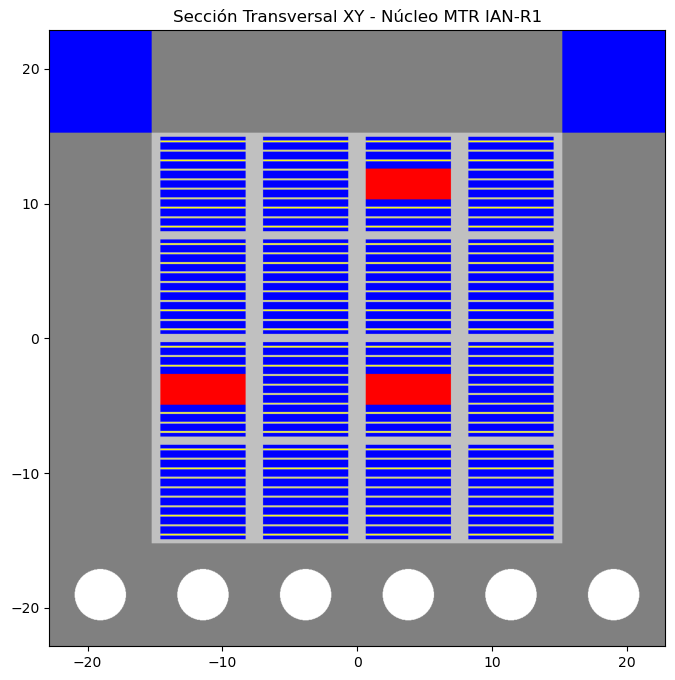

In [6]:
import matplotlib.pyplot as plt

plot_args = {
    'width': (6 * bundle_pitch, 6 * bundle_pitch), 
    'pixels': (1200, 1200), 
    'basis': 'xy',
    'origin': (0.0, 0.0, -36.03), 
    'color_by': 'material',
    'colors': {
        water: 'blue',             
        u_al_meat: 'yellow',       
        al1100: 'silver',          
        graphite: 'gray',          
        borated_ss: 'red',         
        air: 'white'               
    }
}
fig, ax = plt.subplots(figsize=(8, 8))
bundle_universe.plot(**plot_args, axes=ax)
ax.set_title("Sección Transversal XY - Núcleo MTR IAN-R1")
plt.show()

In [7]:
#Parametros de simulacion

batches = 250
inactive = 50
particles = 50000

settings_file = openmc.Settings()
settings_file.batches = batches
settings_file.inactive = inactive
settings_file.particles = particles

#Coorednada exacta de generacion
exact_point = openmc.stats.Point(xyz=(-3.81, 1.7742, -36.03))

#Fuente
source = openmc.IndependentSource(space=exact_point)
settings_file.source = source

#Malla - Entropia
x_bound = (6 * 7.62) / 2 # 22.86 cm
z_min = -36.03 - (59.37/2)
z_max = -36.03 + (59.37/2)
bounds = [-x_bound, -x_bound, z_min, x_bound, x_bound, z_max]

entropy_mesh = openmc.RegularMesh()
entropy_mesh.lower_left = bounds[:3]
entropy_mesh.upper_right = bounds[3:]
entropy_mesh.dimension = [10, 10, 10]
settings_file.entropy_mesh = entropy_mesh

settings_file.export_to_xml()

In [8]:
#Mallas y tallies

z_center = -36.03
active_height = 59.37
z_min = z_center - active_height/2
z_max = z_center + active_height/2

#Malla flujo
mesh = openmc.RegularMesh()
mesh.dimension = [200, 200, 1]
mesh.lower_left = [-24.0, -24.0, z_min]
mesh.upper_right = [24.0, 24.0, z_max]

mesh_filter = openmc.MeshFilter(mesh)

flux_map_tally = openmc.Tally(name='flux_map')
flux_map_tally.filters = [mesh_filter]
flux_map_tally.scores = ['flux']

#Malla letargia
energy_bins = np.logspace(-5, np.log10(20e6), 501)
energy_filter = openmc.EnergyFilter(energy_bins)

spectrum_tally = openmc.Tally(name='flux_spectrum')
spectrum_tally.filters = [energy_filter]
spectrum_tally.scores = ['flux']

#Tasas reaccion
rxn_tally = openmc.Tally(name='reaction_rates')
rxn_tally.scores = ['fission', 'absorption', 'scatter']

tallies = openmc.Tallies([flux_map_tally, spectrum_tally, rxn_tally])
tallies.export_to_xml()

In [9]:
openmc.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

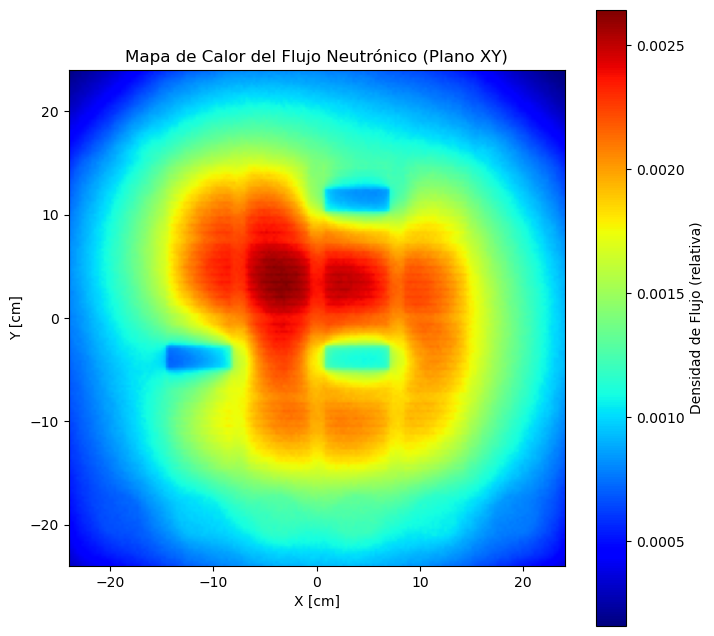

In [10]:
sp = openmc.StatePoint('statepoint.250.h5')
flux_tally = sp.get_tally(name='flux_map')

flux_mean = flux_tally.get_values(value='mean').reshape((200, 200))

#Mapa de calor
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(flux_mean, origin='lower', extent=[-24.0, 24.0, -24.0, 24.0], cmap='jet')
plt.colorbar(im, label='Densidad de Flujo (relativa)')
ax.set_title('Mapa de Calor del Flujo Neutrónico (Plano XY)')
ax.set_xlabel('X [cm]')
ax.set_ylabel('Y [cm]')
plt.show()

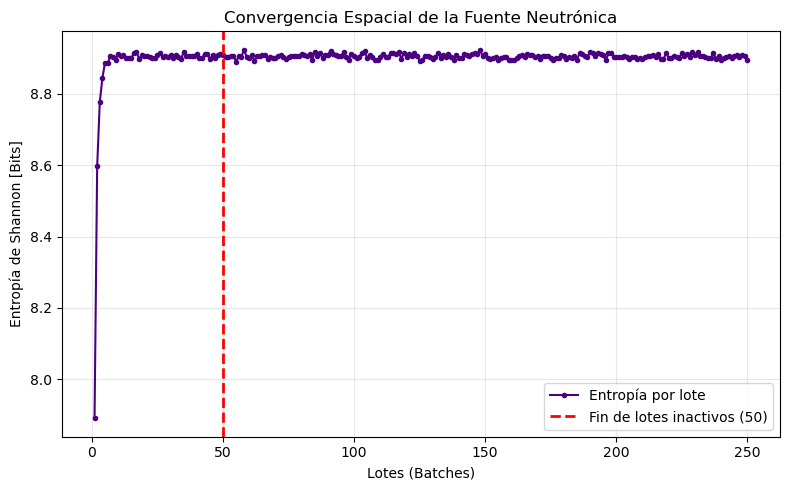

In [11]:
#Grafica entropia

sp = openmc.StatePoint('statepoint.250.h5')

entropy = sp.entropy
batches = range(1, len(entropy) + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(batches, entropy, marker='o', markersize=3, linestyle='-', color='indigo', label='Entropía por lote')

ax.axvline(x=50, color='red', linestyle='--', linewidth=2, label='Fin de lotes inactivos (50)')

ax.set_xlabel('Lotes (Batches)')
ax.set_ylabel('Entropía de Shannon [Bits]')
ax.set_title('Convergencia Espacial de la Fuente Neutrónica')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

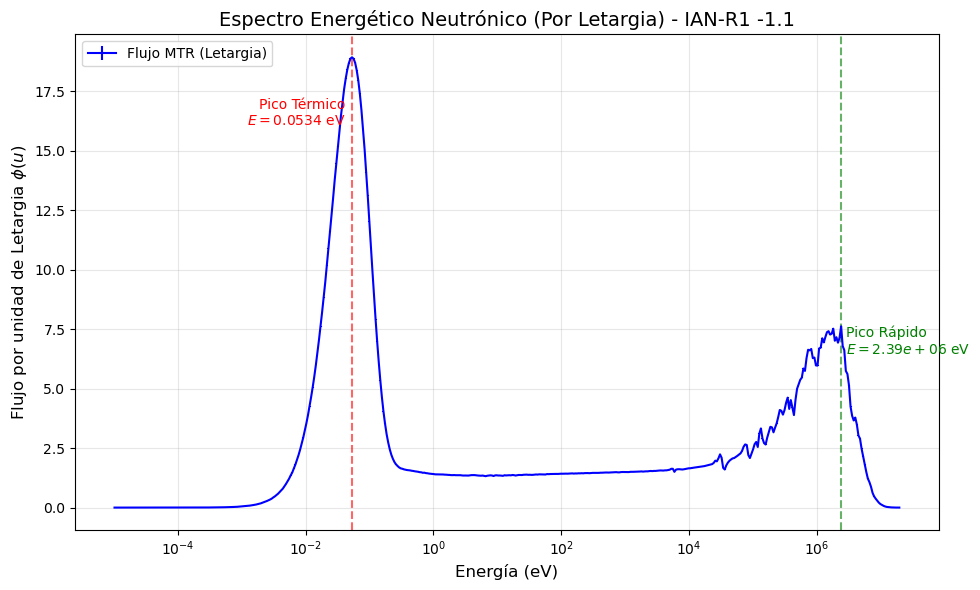

In [12]:
#Grafica letargia

sp = openmc.StatePoint('statepoint.250.h5')
spectrum_tally = sp.get_tally(name='flux_spectrum')

flux = spectrum_tally.get_values(value='mean').flatten()
flux_unc = spectrum_tally.get_values(value='std_dev').flatten()

energy_bounds = spectrum_tally.filters[0].bins
energy_centers = 0.5 * (energy_bounds[:, 0] + energy_bounds[:, 1])
lethargy_widths = np.log(energy_bounds[:, 1] / energy_bounds[:, 0])

flux_lethargy = flux / lethargy_widths
flux_unc_lethargy = flux_unc / lethargy_widths

thermal_mask = energy_centers < 1.0
E_thermal_region = energy_centers[thermal_mask]
flux_thermal_region = flux_lethargy[thermal_mask]

idx_max_thermal = np.argmax(flux_thermal_region)
E_peak_thermal = E_thermal_region[idx_max_thermal]
val_peak_thermal = flux_thermal_region[idx_max_thermal]

fast_mask = energy_centers > 1e5
E_fast_region = energy_centers[fast_mask]
flux_fast_region = flux_lethargy[fast_mask]

idx_max_fast = np.argmax(flux_fast_region)
E_peak_fast = E_fast_region[idx_max_fast]
val_peak_fast = flux_fast_region[idx_max_fast]

fig1, ax1 = plt.subplots(figsize=(10, 6))

ax1.errorbar(energy_centers, flux_lethargy, yerr=flux_unc_lethargy, 
             fmt='-', color='b', linewidth=1.5, label='Flujo MTR (Letargia)')

ax1.set_xscale('log')
ax1.set_xlabel('Energía (eV)', fontsize=12)
ax1.set_ylabel(r'Flujo por unidad de Letargia $\phi(u)$', fontsize=12)
ax1.set_title('Espectro Energético Neutrónico (Por Letargia) - IAN-R1 -1.1', fontsize=14)

ax1.axvline(x=E_peak_thermal, color='red', linestyle='--', alpha=0.6)
ax1.text(E_peak_thermal * 0.8, val_peak_thermal * 0.85, 
         f'Pico Térmico\n$E = {E_peak_thermal:.4f}$ eV', color='red', ha='right')

ax1.axvline(x=E_peak_fast, color='green', linestyle='--', alpha=0.6)
ax1.text(E_peak_fast * 1.2, val_peak_fast * 0.85, 
         f'Pico Rápido\n$E = {E_peak_fast:.2e}$ eV', color='green', ha='left')

ax1.grid(True, which="both", ls="-", alpha=0.3)
ax1.legend()
plt.tight_layout()
